### There are three stages of building an LLM. 

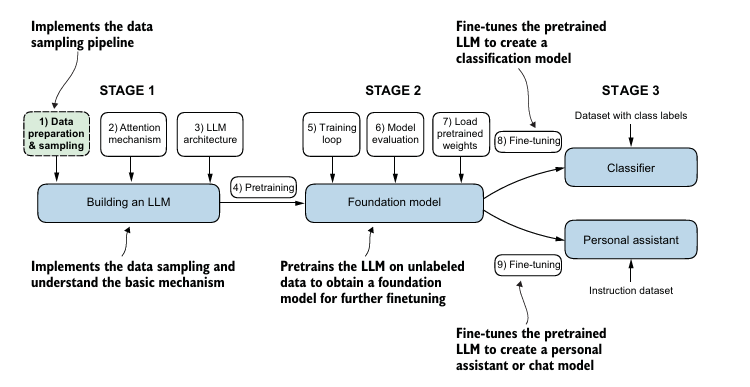

## We are going to cover

- Preparing text for large language model training
- Splitting text into word and subword tokens
- Byte pair encoding as a more advanced way of tokenizing text
-  Sampling training examples with a sliding window approach
- Converting tokens into vectors that feed into a large language model

#### Understanding word embeddings. 
- Deep neural networks models, including LLMs, cannot process raw text directly. Therefore, we neeed a way to represent words as continuous-valued vectors. 

- The concept of converting data into a vector is often reffered to as embeddings. 

- We can enbed different data types--for example, video, audio and text.
- Different data formats require distinct embedding models. 

### Tokenizing text 

- we split input text into individual tokens. 
- These tokens are either individual words orspecial characters


In [2]:
## Reading the text 
with open(r"D:\lokesh\DS\LLM_from-scratch\the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [3]:
# split the text on whitespace characters
import re
text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)
print(result)


['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [4]:
# splits on whitespaces (\s), commas, and periods ([,.])
result = re.split(r'([,.]|\s)', text)
print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


In [5]:
# remove redundant characters
result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


In [6]:
#  handle other types of punctuation, such as question marks, quotation marks, and the double-dashes as our text have. 
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


our tokenization scheme can now handle the various special characters in the text successfully

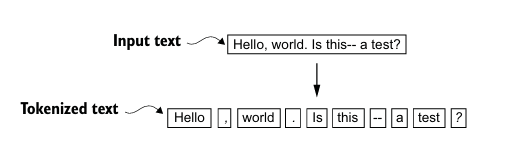

Let's apply this basic tokenizer to Edith Wharton’s entire
short story

In [7]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))

4690


In [8]:
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


### Converting tokens into token IDs

-  let’s convert these tokens from a Python string to an integer representation to produce the token IDs

- To map the previously generated tokens into token IDs, we have to build a vocabulary first

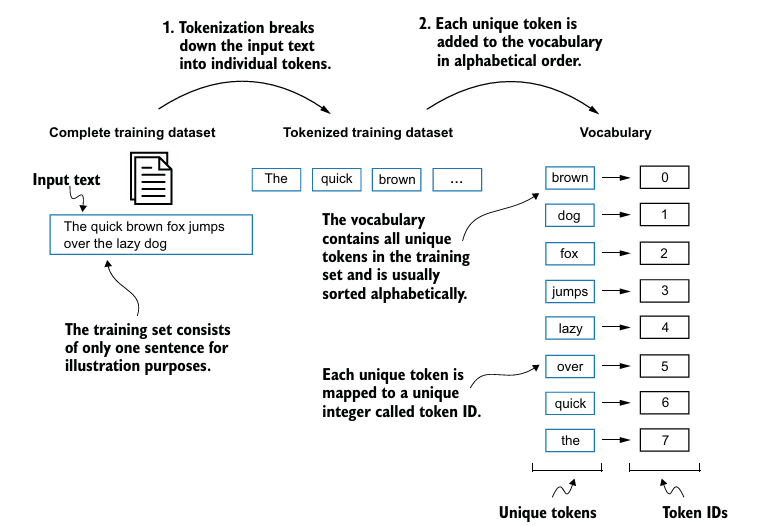

In [9]:
# let's create a list of all unique tokens 
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)

1130


#### - creating a vocabulary 

In [10]:
vocab = {token:integer for integer,token in enumerate(all_words)}
print(vocab)
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

{'!': 0, '"': 1, "'": 2, '(': 3, ')': 4, ',': 5, '--': 6, '.': 7, ':': 8, ';': 9, '?': 10, 'A': 11, 'Ah': 12, 'Among': 13, 'And': 14, 'Are': 15, 'Arrt': 16, 'As': 17, 'At': 18, 'Be': 19, 'Begin': 20, 'Burlington': 21, 'But': 22, 'By': 23, 'Carlo': 24, 'Chicago': 25, 'Claude': 26, 'Come': 27, 'Croft': 28, 'Destroyed': 29, 'Devonshire': 30, 'Don': 31, 'Dubarry': 32, 'Emperors': 33, 'Florence': 34, 'For': 35, 'Gallery': 36, 'Gideon': 37, 'Gisburn': 38, 'Gisburns': 39, 'Grafton': 40, 'Greek': 41, 'Grindle': 42, 'Grindles': 43, 'HAD': 44, 'Had': 45, 'Hang': 46, 'Has': 47, 'He': 48, 'Her': 49, 'Hermia': 50, 'His': 51, 'How': 52, 'I': 53, 'If': 54, 'In': 55, 'It': 56, 'Jack': 57, 'Jove': 58, 'Just': 59, 'Lord': 60, 'Made': 61, 'Miss': 62, 'Money': 63, 'Monte': 64, 'Moon-dancers': 65, 'Mr': 66, 'Mrs': 67, 'My': 68, 'Never': 69, 'No': 70, 'Now': 71, 'Nutley': 72, 'Of': 73, 'Oh': 74, 'On': 75, 'Once': 76, 'Only': 77, 'Or': 78, 'Perhaps': 79, 'Poor': 80, 'Professional': 81, 'Renaissance': 82, 'Ri

In [11]:
#  Implementing a simple text tokenizer

class SimpleTokenizerV1:

    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {integer: token for token, integer in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])

        text = re.sub(r'\s+([,.?"!()\'])', r'\1', text)
        return text

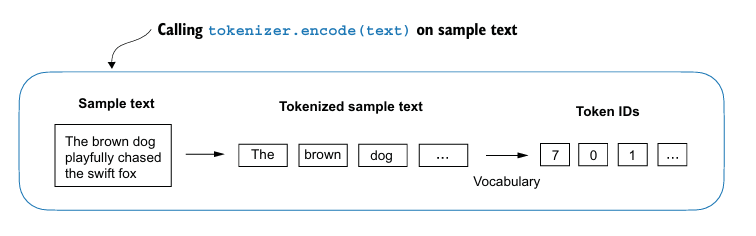

In [12]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know," 
       Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


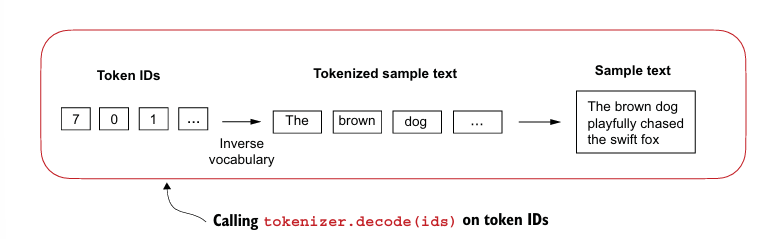

In [13]:
print(tokenizer.decode(ids))

" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


In [14]:
text = "Hello, do you like tea?"
print(tokenizer.encode(text))

KeyError: 'Hello'

The problem is that the word “Hello” was not used in the “The Verdict” short story.
Hence, it is not contained in the vocabulary. 

### Adding special context tokens

- we add an <|unk|> token to represent new and unknown words that were not part of the training data and thus not part of the existing vocabulary

-  we add an <|endoftext|> token that we can use to separate two unrelated text sources

In [15]:
# Let’s now modify the vocabulary to include these two special tokens

all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token:integer for integer,token in enumerate(all_tokens)}
print(len(vocab.items()))

1132


In [16]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [17]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        preprocessed = [item if item in self.str_to_int           
                        else "<|unk|>" for item in preprocessed]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
    
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)   
        return text

In [18]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [19]:
tokenizer = SimpleTokenizerV2(vocab)
print(tokenizer.encode(text))

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]


In [20]:
print(tokenizer.decode(tokenizer.encode(text)))

<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


```
we have used custom Tokenizer class for text tokenization in which we were using <|unk|> for Out of vocabulary words. 
But GPT model doesn't use an <|unk|> token for OOV words. Instead, GPT models use a  byte pair encoding tokenizer, which breaks words down into subword units,

#### Byte pair encoding

- The algorithm underlying BPE breaks down words that aren’t in its predefined
vocabulary into smaller subword units or even individual characters, enabling it to handle out-of-vocabulary words.

- we will use an existing Python open source library called tiktoken

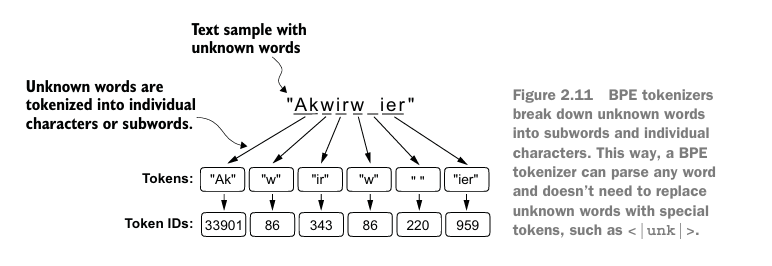

In [21]:
from importlib.metadata import version
import tiktoken
print("tiktoken version: ", version("tiktoken"))

tiktoken version:  0.13.0


In [22]:
tokenizer = tiktoken.get_encoding("gpt2")

In [23]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [24]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


### Data sampling with a sliding window

The next step in creating the embeddings for the LLM is to generate the input–target pairs required for training an LLM.

In [25]:
with open(r"D:\lokesh\DS\LLM_from-scratch\the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [26]:
enc_sample = enc_text[50:]

context_size = 4        
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [27]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [28]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


In [29]:
#  A dataset for batched inputs and targets
import torch 
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride): #Uses a sliding window to chunk the book into overlapping sequences of max_length
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, index):
        return self.input_ids[index], self.target_ids[index]
    

In [35]:
# A data loader to generate batches with input-with pairs

def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last= True, 
                         num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset=dataset,
        batch_size = batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )

    return dataloader

In [39]:
with open(r"D:\lokesh\DS\LLM_from-scratch\the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

dataloader = create_dataloader_v1(txt= raw_text,
                                  batch_size=1, 
                                  max_length=8, 
                                  stride=2, shuffle=False)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464, 1807, 3619,  402,  271]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899]])]


The first_batch variable contains two tensors: the first tensor stores the input token IDs, and the second tensor stores the target token IDs. 

In [40]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 2885,  1464,  1807,  3619,   402,   271, 10899,  2138]]), tensor([[ 1464,  1807,  3619,   402,   271, 10899,  2138,   257]])]


In [41]:
# Let’s look briefly at how we can use the data loader to sample with a batch size greater than 1

dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4,shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs: \n", inputs)
print("\nTargets: \n", targets)

Inputs: 
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets: 
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


### Creating token embeddings

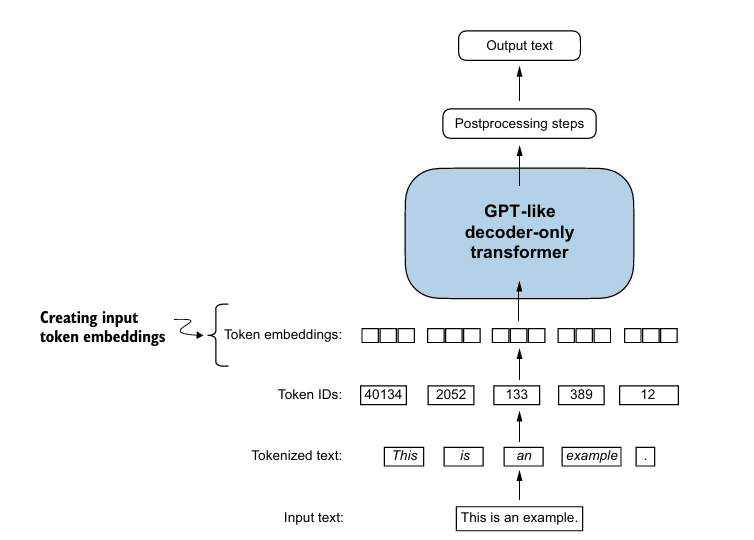

In [45]:
# for the sake of simplicity, suppose we have small vocabulary of 6 words and we want to create embeddings of size 3

vocab_size = 6
output_dim = 3 

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [46]:
#  let’s apply it to a token ID to obtain the embedding vector
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [47]:
input_ids = torch.tensor([2,3,5,1])

print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


#### Encoding word positions

In [48]:
vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [52]:
# print(token_embedding_layer(torch.tensor([3])))

max_length = 4

dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=max_length,
                                  stride=max_length, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Token IDs: \n", inputs)
print("\n Inputs shape: \n", inputs.shape)

Token IDs: 
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

 Inputs shape: 
 torch.Size([8, 4])


In [53]:
# Let’s now use the embedding layer to embed these token IDs into 256-dimensional vectors

token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)


torch.Size([8, 4, 256])


In [59]:
token_embeddings[0]

tensor([[ 0.4913,  1.1239,  1.4588,  ..., -0.3995, -1.8735, -0.1445],
        [ 0.4481,  0.2536, -0.2655,  ...,  0.4997, -1.1991, -1.1844],
        [-0.2507, -0.0546,  0.6687,  ...,  0.9618,  2.3737, -0.0528],
        [ 0.9457,  0.8657,  1.6191,  ..., -0.4544, -0.7460,  0.3483]],
       grad_fn=<SelectBackward0>)

In [63]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embedding = pos_embedding_layer(torch.arange(context_length))
print(pos_embedding.shape)

torch.Size([4, 256])


In [65]:
input_embeddings = token_embeddings + pos_embedding
print(input_embeddings.shape)

torch.Size([8, 4, 256])


we have created input embeddings 

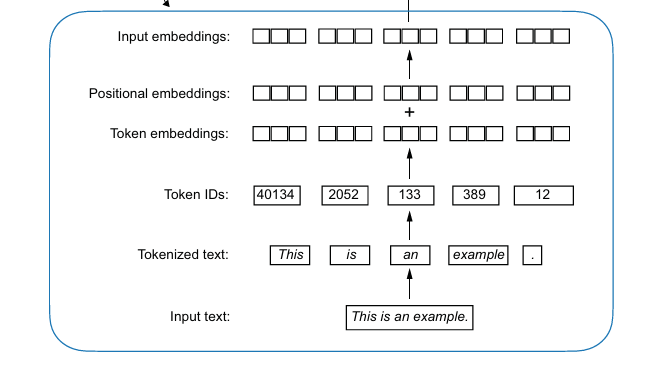